In [2]:
import sys
from pathlib import Path

# Add project root (parent of notebooks/) to the path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [3]:
from src.data import (
    load_dataset,
    get_basic_statistics,
    detect_frequency,
    check_missing_values,
    get_series_statistics,
    get_series_coverage,
    detect_seasonality,
    summarize_seasonality,
    inspect_dataset
)

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
DATA_PATH = project_root / "data" / "raw" / "LD2011_2014.txt"

## Load dataset

In [5]:
df = load_dataset(DATA_PATH)

print("Shape:", df.shape)

display(df.head())

Loading dataset: c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\chronos-2\data\raw\LD2011_2014.txt
Raw shape: (140256, 371)
Shape: (51894720, 3)


,timestamp,series_id,value
0,2011-01-01 00:15:00,MT_001,0.0
1,2011-01-01 00:30:00,MT_001,0.0
2,2011-01-01 00:45:00,MT_001,0.0
3,2011-01-01 01:00:00,MT_001,0.0
4,2011-01-01 01:15:00,MT_001,0.0


## frequency

In [6]:
frequency = detect_frequency(df)

print(
    f"Detected frequency: {frequency}"
)

Detected frequency: 15min


In [7]:
intervals = (
    df.groupby("series_id")["timestamp"]
    .diff()
    .dropna()
)

print(
    intervals.value_counts().head(10)
)

timestamp
0 days 00:15:00    51894350
Name: count, dtype: int64


## Missing values

In [8]:
missing = check_missing_values(df)

print("Missing values:")
print(missing)

Missing values:
{'missing_by_column': {'timestamp': 0, 'series_id': 0, 'value': 0}, 'missing_value_count': 0, 'duplicate_timestamp_series': 0}


In [9]:
print(
    "Missing consumption values:",
    df["value"].isna().sum()
)

Missing consumption values: 0


## number of series

In [10]:
stats = get_basic_statistics(df)

print(
    f"Number of series: "
    f"{stats['number_of_series']}"
)

Number of series: 370


In [11]:
print(
    df["series_id"].nunique()
)

370


In [12]:
series_ids = df["series_id"].unique()

print(series_ids)

['MT_001' 'MT_002' 'MT_003' 'MT_004' 'MT_005' 'MT_006' 'MT_007' 'MT_008'
 'MT_009' 'MT_010' 'MT_011' 'MT_012' 'MT_013' 'MT_014' 'MT_015' 'MT_016'
 'MT_017' 'MT_018' 'MT_019' 'MT_020' 'MT_021' 'MT_022' 'MT_023' 'MT_024'
 'MT_025' 'MT_026' 'MT_027' 'MT_028' 'MT_029' 'MT_030' 'MT_031' 'MT_032'
 'MT_033' 'MT_034' 'MT_035' 'MT_036' 'MT_037' 'MT_038' 'MT_039' 'MT_040'
 'MT_041' 'MT_042' 'MT_043' 'MT_044' 'MT_045' 'MT_046' 'MT_047' 'MT_048'
 'MT_049' 'MT_050' 'MT_051' 'MT_052' 'MT_053' 'MT_054' 'MT_055' 'MT_056'
 'MT_057' 'MT_058' 'MT_059' 'MT_060' 'MT_061' 'MT_062' 'MT_063' 'MT_064'
 'MT_065' 'MT_066' 'MT_067' 'MT_068' 'MT_069' 'MT_070' 'MT_071' 'MT_072'
 'MT_073' 'MT_074' 'MT_075' 'MT_076' 'MT_077' 'MT_078' 'MT_079' 'MT_080'
 'MT_081' 'MT_082' 'MT_083' 'MT_084' 'MT_085' 'MT_086' 'MT_087' 'MT_088'
 'MT_089' 'MT_090' 'MT_091' 'MT_092' 'MT_093' 'MT_094' 'MT_095' 'MT_096'
 'MT_097' 'MT_098' 'MT_099' 'MT_100' 'MT_101' 'MT_102' 'MT_103' 'MT_104'
 'MT_105' 'MT_106' 'MT_107' 'MT_108' 'MT_109' 'MT_1

## Minimum and maximum

In [13]:
print(
    f"Minimum value: {stats['minimum']}"
)

print(
    f"Maximum value: {stats['maximum']}"
)

Minimum value: 0.0
Maximum value: 192800.0


## Dataset Coverage

In [14]:
coverage = get_series_coverage(df)

display(coverage.head(20))

,series_id,start_date,end_date,observations
0,MT_001,2011-01-01 00:15:00,2015-01-01,140256
1,MT_002,2011-01-01 00:15:00,2015-01-01,140256
2,MT_003,2011-01-01 00:15:00,2015-01-01,140256
3,MT_004,2011-01-01 00:15:00,2015-01-01,140256
4,MT_005,2011-01-01 00:15:00,2015-01-01,140256
5,MT_006,2011-01-01 00:15:00,2015-01-01,140256
6,MT_007,2011-01-01 00:15:00,2015-01-01,140256
7,MT_008,2011-01-01 00:15:00,2015-01-01,140256
8,MT_009,2011-01-01 00:15:00,2015-01-01,140256
9,MT_010,2011-01-01 00:15:00,2015-01-01,140256


## Seasonal patterns

In [15]:
seasonality = detect_seasonality(
    df,
    periods=[4, 96, 672]
)

display(
    seasonality.sort_values(
        "autocorrelation",
        ascending=False
    ).head(30)
)

,series_id,period,autocorrelation
441,MT_148,4,0.997718
453,MT_152,4,0.997489
438,MT_147,4,0.997486
429,MT_144,4,0.996105
432,MT_145,4,0.996042
435,MT_146,4,0.995133
430,MT_144,96,0.994766
439,MT_147,96,0.993616
865,MT_289,96,0.993074
1104,MT_369,4,0.992774


In [16]:
seasonality_summary = summarize_seasonality(
    seasonality
)

display(seasonality_summary)

,series_id,period,autocorrelation
0,MT_001,4,0.801439
1,MT_002,4,0.968071
2,MT_003,4,0.846749
3,MT_004,96,0.955910
4,MT_005,4,0.958915
...,...,...,...
365,MT_366,4,0.831480
366,MT_367,4,0.954827
367,MT_368,4,0.943616
368,MT_369,4,0.992774


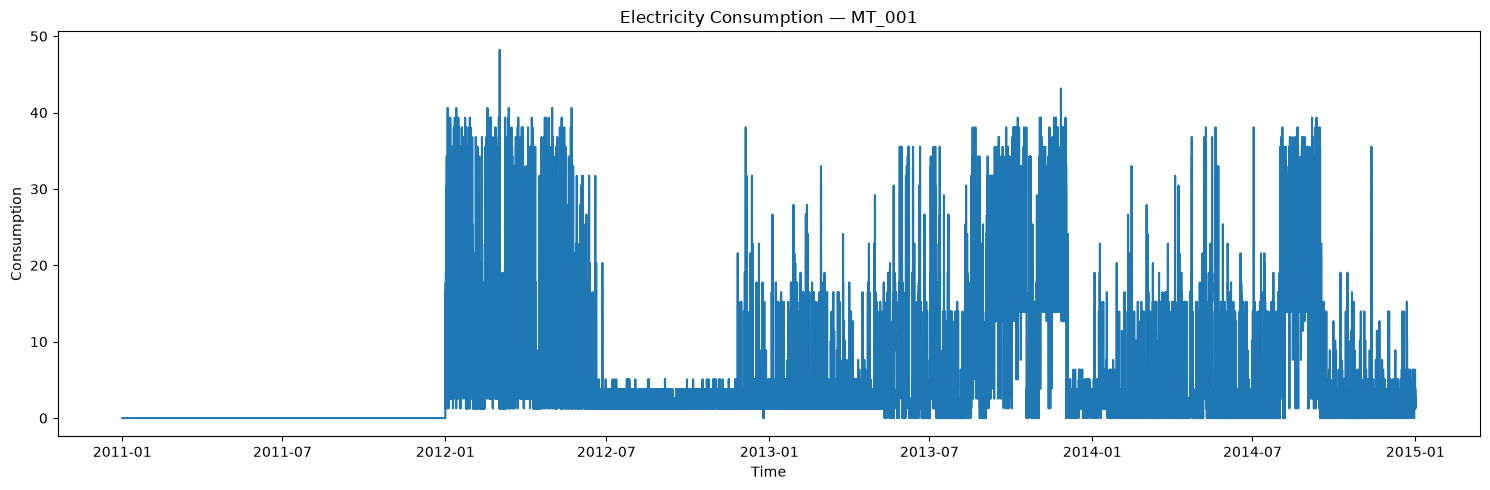

In [17]:
series_id = df["series_id"].iloc[0]

series_df = (
    df[df["series_id"] == series_id]
    .sort_values("timestamp")
)

plt.figure(figsize=(15, 5))

plt.plot(
    series_df["timestamp"],
    series_df["value"]
)

plt.title(
    f"Electricity Consumption — {series_id}"
)

plt.xlabel("Time")
plt.ylabel("Consumption")

plt.tight_layout()
plt.show()

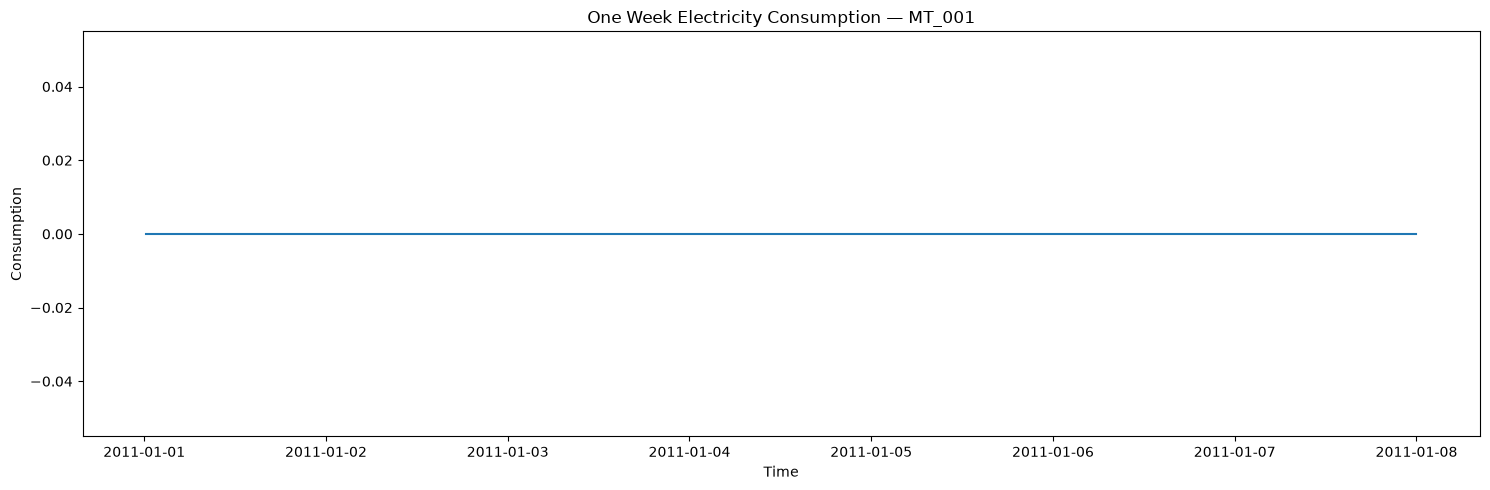

In [18]:
one_week = series_df.iloc[:672]

plt.figure(figsize=(15, 5))

plt.plot(
    one_week["timestamp"],
    one_week["value"]
)

plt.title(
    f"One Week Electricity Consumption — {series_id}"
)

plt.xlabel("Time")
plt.ylabel("Consumption")

plt.tight_layout()
plt.show()

In [20]:
df, report = inspect_dataset(
     project_root / "data" / "raw" / "LD2011_2014.txt"
)

print(report)

Loading dataset: c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\chronos-2\data\raw\LD2011_2014.txt
Raw shape: (140256, 371)

DAY 3 — DATASET INSPECTION
Observations       : 51,894,720
Number of series   : 370
Frequency          : 15min
Start date         : 2011-01-01 00:15:00
End date           : 2015-01-01 00:00:00
Minimum value      : 0.0
Maximum value      : 192800.0

Missing Values
----------------------------------------------------------------------
timestamp           : 0
series_id           : 0
value               : 0

Duplicate timestamp-series pairs : 0
{'observations': 51894720, 'number_of_series': 370, 'minimum': np.float64(0.0), 'maximum': np.float64(192800.0), 'start_date': Timestamp('2011-01-01 00:15:00'), 'end_date': Timestamp('2015-01-01 00:00:00'), 'frequency': '15min', 'missing_by_column': {'timestamp': 0, 'series_id': 0, 'value': 0}, 'missing_value_count': 0, 'duplicate_timestamp_series': 0}
